# Block 2 — Advanced Feature Engineering: Dirty Data & Imputation
### Advanced Machine Learning — M&T Bank

**Dataset:** `bank_marketing.csv` (UCI Bank Marketing, 41,188 rows × 21 columns) — the dataset we'll reuse through the rest of the course.

**What we'll do in this notebook:**
1. Load and profile the data — find where the dirty values are hiding
2. Learn the three reasons a value goes missing — MCAR, MAR, MNAR — and why the difference matters
3. Actually diagnose which mechanism we're looking at, column by column, using our own data
4. Apply fixes that match the mechanism, with `pandas` and `scikit-learn`
5. Save a clean version of the dataset for the rest of the course to build on


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer

pd.set_option("display.max_columns", 25)

# Course palette, purely cosmetic
NAVY = "#251E4E"
PINK = "#FF1675"
GRAY = "#6b7280"
ORANGE = "#FF7B01"


## 2. Load & First Look

In [ ]:
# Data source: https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing.csv
df = pd.read_csv("https://raw.githubusercontent.com/mithun-rk/mt-advml-course/main/Data/bank_marketing.csv", sep=";")
print(df.shape)
df.head()


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

Notice: `df.info()` reports **zero nulls** on every column. If we stopped here, we'd conclude this dataset is clean.
It isn't — the missing values are just disguised as real-looking strings and numbers instead of `NaN`. That's the whole lesson of this block.


## 3. Finding the Hidden Missing Values — Categorical Columns

In [4]:
categorical_cols = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "day_of_week", "poutcome",
]

unknown_summary = (
    pd.DataFrame({
        "column": categorical_cols,
        "n_unknown": [(df[c] == "unknown").sum() for c in categorical_cols],
    })
    .assign(pct_unknown=lambda d: (d["n_unknown"] / len(df) * 100).round(1))
    .query("n_unknown > 0")
    .sort_values("pct_unknown", ascending=False)
    .reset_index(drop=True)
)
unknown_summary


,column,n_unknown,pct_unknown
0,default,8597,20.9
1,education,1731,4.2
2,housing,990,2.4
3,loan,990,2.4
4,job,330,0.8
5,marital,80,0.2


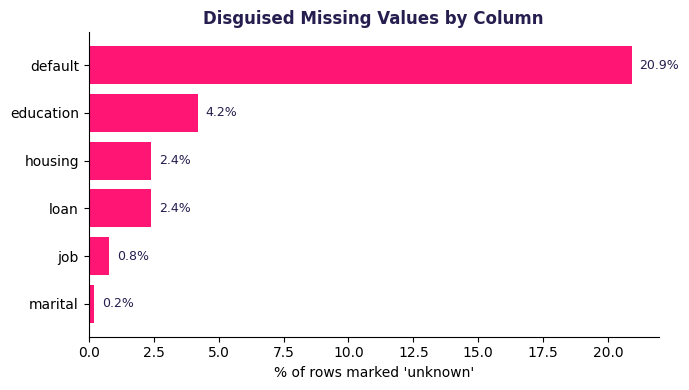

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(unknown_summary["column"], unknown_summary["pct_unknown"], color=PINK)
ax.set_xlabel("% of rows marked 'unknown'")
ax.set_title("Disguised Missing Values by Column", color=NAVY, fontweight="bold")
ax.invert_yaxis()
for b in bars:
    ax.text(b.get_width() + 0.3, b.get_y() + b.get_height() / 2,
            f"{b.get_width():.1f}%", va="center", fontsize=9, color=NAVY)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**Talking point:** `default` stands out at ~21% unknown — far more than any other column. That's a lot of data to be
missing "by accident." Worth asking out loud: *why* would someone not answer whether they've ever defaulted? We'll
come back to this exact question with a name for it in a moment.


## 4. Finding the Hidden Missing Values — Numeric Sentinels

In [6]:
print(df["pdays"].describe())
print()
print("Rows where pdays == 999 (sentinel for 'never previously contacted'):",
      (df["pdays"] == 999).sum(), "of", len(df))


count    41188.000000
mean       962.475454
std        186.910907
min          0.000000
25%        999.000000
50%        999.000000
75%        999.000000
max        999.000000
Name: pdays, dtype: float64

Rows where pdays == 999 (sentinel for 'never previously contacted'): 39673 of 41188


`999` isn't a real day count — it's a sentinel meaning *"this client was never contacted in a previous campaign."*
Left untreated, it would sit in the data as an enormous, meaningless outlier: any distance-based method (KNN, SVM) or
linear model would treat "999 days" as 900+ days more contact history than everyone else, which is nonsense.

**Worth flagging as a different case from everything else in this notebook:** `pdays == 999` isn't really *missing*
in the sense we're about to define — there's no true, unrecorded day-count hiding behind it. "Never contacted before"
is itself the real, fully-known answer; it's just been encoded as a number instead of a category. The three
mechanisms below (MCAR/MAR/MNAR) describe *why a real value failed to get recorded* — they don't apply to a
sentinel standing in for a legitimately different state. Keep that distinction in mind as we go.


## 5. Why Missingness Happens: MCAR, MAR, MNAR

Before choosing *how* to fix a missing value, it's worth knowing *why* it's missing — because that's what actually
determines whether imputation can honestly solve the problem, or whether you're stuck with an unavoidable blind
spot. There are three recognized mechanisms.

### MCAR — Missing Completely At Random
The chance a value is missing has nothing to do with anything in the dataset, observed or not — pure randomness.
*Example: a lab sample gets physically dropped, or a server glitch randomly loses a few survey responses.*
Since the missing subset is essentially a random sample of the whole dataset, dropping those rows (or even simple
imputation) doesn't introduce bias — you just lose some statistical power from fewer data points.

### MAR — Missing At Random *(a genuinely confusing name — it does not mean "random" in the everyday sense)*
The chance a value is missing depends on **other observed variables** in the dataset, but not on the missing value
itself. *Example: in a survey, men are less likely than women to answer a question about mental health —
missingness depends on gender (which you do observe), not directly on the actual unobserved answer.*
This is recoverable: if your imputation method accounts for the observed variable driving the missingness (e.g.,
regression-based or KNN imputation that uses gender as a predictor), you can correct for the bias. Naive mean/mode
imputation, which ignores other features entirely, is risky here — proper *conditional* imputation is not.

### MNAR — Missing Not At Random *(sometimes NMAR)*
The chance a value is missing depends on **the missing value itself**, even after accounting for everything you
did observe. *Example: very high earners are less likely to report their income — the reason it's missing is tied
directly to the income figure you don't have.*
This is the dangerous one: no amount of clever imputation using other observed features fully fixes it, because the
mechanism causing the gap is baked into the unobserved quantity itself. This usually needs domain investigation,
sensitivity analysis, or specialized modeling — not a standard imputation technique.

**The punchline:** figuring out which of these three you're dealing with is what actually tells you whether
imputation can honestly solve the problem — so let's stop guessing and go check, column by column, in our own data.


## 6. Diagnosing Our Own Missingness

We can't directly *prove* any of these three from data alone — MCAR and MNAR in particular are, by definition,
about things we can't fully observe. But we *can* look for evidence: does a column's missingness rate move
systematically with another variable we do observe? If it does, that's evidence against MCAR and consistent with
either MAR or MNAR — and gives us a real lead to reason about further.

### 6.1 — Does missingness vary with an observed variable? (`age`)


In [7]:
# Scratch copy for diagnostics only -- keeps df itself untouched, so the columns we save later
# stay exactly the ones the rest of the course expects.
diag = df.copy()

age_bins = [17, 25, 35, 45, 55, 65, 98]
age_labels = ["18-25", "26-35", "36-45", "46-55", "56-65", "66+"]
diag["age_band"] = pd.cut(diag["age"], bins=age_bins, labels=age_labels, include_lowest=True)

low_unknown_cols = ["job", "marital", "education", "housing", "loan"]
for c in low_unknown_cols:
    diag[c + "_is_missing"] = (diag[c] == "unknown").astype(int)

missingness_by_age = (
    diag.groupby("age_band", observed=True)[[c + "_is_missing" for c in low_unknown_cols]].mean() * 100
).round(2)
missingness_by_age.columns = low_unknown_cols
missingness_by_age


,job,marital,education,housing,loan
age_band,,,,,
18-25,0.48,0.12,7.74,2.82,2.82
26-35,0.47,0.26,2.28,2.39,2.39
36-45,0.73,0.10,4.17,2.27,2.27
46-55,1.19,0.22,5.26,2.57,2.57
56-65,1.69,0.24,7.80,2.43,2.43
66+,1.62,0.32,10.18,1.94,1.94


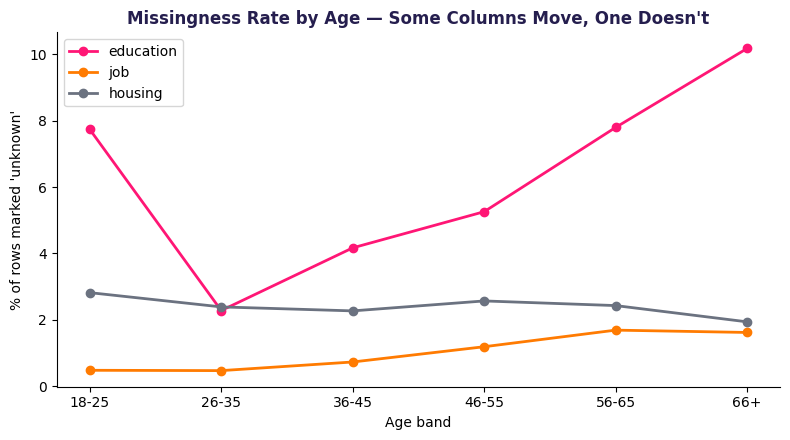

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = {"education": PINK, "job": ORANGE, "housing": GRAY}
for col in ["education", "job", "housing"]:
    ax.plot(missingness_by_age.index, missingness_by_age[col], marker="o", linewidth=2,
            color=colors[col], label=col)
ax.set_ylabel("% of rows marked 'unknown'")
ax.set_xlabel("Age band")
ax.set_title("Missingness Rate by Age — Some Columns Move, One Doesn't", color=NAVY, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


**What the data actually shows:**
- **`education`** ranges from 2.3% (ages 26-35) up to 10.2% (66+) — a **4.5x spread**, elevated at both ends of the
  age range. That's a clear, systematic relationship with an observed variable (age).
- **`job`** climbs fairly steadily from 0.5% (18-35) to 1.7% (56-65) — a **3.6x spread**, smaller in absolute terms
  but the same kind of age-linked pattern.
- **`housing`** barely moves — 1.9% to 2.8%, a **1.5x spread** with no clear direction. Consistent with no strong
  observed driver at all.

**Reading:** `education` and `job` show real evidence of **MAR** — their missingness depends on something we
observe (age), not on the unobserved value itself. `housing` shows no such pattern, which is at least consistent
with **MCAR** (we can never fully *confirm* MCAR — only fail to find evidence against it). `marital` and `loan`
(not plotted — both under 2.4% overall, similarly flat by age) fall into the same MCAR-consistent bucket as
`housing`.


### 6.2 — `default`: the same test, and one more


In [9]:
diag["default_is_missing"] = (diag["default"] == "unknown").astype(int)

print("default-unknown rate by marital status:")
print((diag.groupby("marital")["default_is_missing"].mean() * 100).round(1))
print()
print("default-unknown rate by age band:")
print((diag.groupby("age_band", observed=True)["default_is_missing"].mean() * 100).round(1))
print()
print("default-unknown rate by campaign outcome (y) -- does missingness relate to what we're trying to predict?")
print((diag.groupby("y")["default_is_missing"].mean() * 100).round(1))


default-unknown rate by marital status:
marital
divorced    18.0
married     25.2
single      12.8
unknown     13.8
Name: default_is_missing, dtype: float64

default-unknown rate by age band:


age_band
18-25     8.0
26-35    12.2
36-45    23.8
46-55    31.5
56-65    31.8
66+       8.6
Name: default_is_missing, dtype: float64

default-unknown rate by campaign outcome (y) -- does missingness relate to what we're trying to predict?
y
no     22.3
yes     9.5
Name: default_is_missing, dtype: float64


`default`'s missingness moves even more sharply than `education`'s — by marital status (12.8% for single clients vs.
25.2% for married), by age (8.0% at 18-25 up to 31.8% at 56-65), and, notably, **by the outcome we're trying to
predict**: clients who ultimately said "no" have a 22.3% default-unknown rate, versus just 9.6% among clients who
said "yes."

**Here's the honest limit of what data alone can tell us:** all of this is technically evidence for MAR — every
variable we just checked is observed. But domain reasoning pushes further. It's plausible that the real mechanism
is simpler and darker: *clients who have actually defaulted are the ones choosing not to disclose it.* If that's
true, the missingness depends on the unobserved default status itself — which is, by definition, **MNAR** — and no
statistical test run on the data we have can ever fully rule that explanation out or confirm it over the MAR one.
That ambiguity isn't a gap in our analysis; it's the defining feature of MNAR. This is exactly the kind of finding
that needs a domain conversation (with collections, underwriting, or whoever owns this data at intake) — not a
fancier imputer.


## 7. Deciding a Strategy — Matched to the Mechanism

| Column | Best evidence | Strategy | Why |
|---|---|---|---|
| `marital`, `loan` | MCAR-consistent — flat by age, <2.5% volume | Impute (mode) | No detected observed driver; low volume, low risk either way |
| `housing` | MCAR-consistent — flat by age | Impute (mode) | Same reasoning as above |
| `job` | MAR — rises with age (0.5% → 1.7%) | Impute (mode), *pragmatically* | Volume is low enough (0.8%) that the bias from ignoring age is small in practice |
| `education` | MAR — rises with age (2.3% → 10.2%) | Impute (mode) *for now*, KNN preview shown below | Volume (4.2%) is high enough that a conditional method is the more defensible choice if this were going to production |
| `default` | MAR on observed vars, plausibly **MNAR** on domain grounds | **Keep as its own category** | Too much volume (20.9%) and too plausible a link to the true unobserved value to guess at |
| `pdays` | Not missing — a sentinel for a real, known state | **Flag, don't impute** | Create `was_contacted_before`; deeper outlier treatment comes in Block 9 |


## 8. Imputing the Low-Unknown Categorical Columns

We're mode-imputing all five columns below for pace and simplicity — this is a defensible, pragmatic choice for
`marital`, `housing`, `loan` (MCAR-consistent) and for `job` given how little volume is involved. For `education`,
it's a conscious trade-off: we know from Section 6 that it's MAR, so mode imputation will quietly ignore the
age-related pattern in what's missing. Section 11 shows what a MAR-aware fix actually looks like.


In [10]:
imputer = SimpleImputer(missing_values="unknown", strategy="most_frequent")

df_clean = df.copy()
df_clean[low_unknown_cols] = imputer.fit_transform(df_clean[low_unknown_cols])

# sanity check — no more "unknown" left in these columns
for c in low_unknown_cols:
    print(c, "-> remaining 'unknown':", (df_clean[c] == "unknown").sum())


job -> remaining 'unknown': 0
marital -> remaining 'unknown': 0
education -> remaining 'unknown': 0
housing -> remaining 'unknown': 0
loan -> remaining 'unknown': 0


`SimpleImputer(missing_values="unknown", strategy="most_frequent")` works directly on our real disguised-missing values —
no need to convert anything to `NaN` first. This is the same imputer you'd use for numeric mean/median imputation,
just pointed at the actual missing-value marker this dataset uses.


## 9. `default` — Deliberately *Not* Imputing

In [11]:
print(df_clean["default"].value_counts())


default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64


We leave `default` exactly as it is. `"unknown"` stays a valid category the model can learn from — we are not
guessing 8,597 values we don't have. This is a decision, not an oversight, and it's worth documenting as one:
*"default's missingness shows evidence of MAR on observed variables (age, marital status) and is plausibly MNAR on
domain grounds (clients who defaulted may be the ones not disclosing it) — no standard imputation technique can
fully resolve that ambiguity, so it is retained as an explicit category pending domain investigation."* That's the
kind of note a model risk reviewer wants to see — it names the mechanism, not just the missing-value count.


## 10. Fixing the `pdays` Sentinel

In [12]:
df_clean["was_contacted_before"] = (df_clean["pdays"] != 999).astype(int)

print(df_clean["was_contacted_before"].value_counts())
df_clean[["pdays", "was_contacted_before"]].head()


was_contacted_before
0    39673
1     1515
Name: count, dtype: int64


,pdays,was_contacted_before
0,999,0
1,999,0
2,999,0
3,999,0
4,999,0


`pdays` itself is left in place for now — a full outlier treatment (capping, transforming, or dropping it in favor of
the flag alone) is exactly what Block 9 (Handling Outliers) covers. For today, the important fix is making sure the
sentinel can no longer masquerade as a real numeric value without at least a flag alongside it to explain it.


## 11. What MAR-Aware Imputation Actually Looks Like (KNN)

Section 6 found real evidence that `education`'s missingness is **MAR**, driven by `age`. Mode imputation from
Section 8 ignores that completely — every imputed value gets pulled toward the same most-common category,
regardless of the client's age. A model-based imputer can do better *because* it can use `age` (and other features)
as predictors, which is exactly what the MAR mechanism calls for.

This is a preview, not something we're applying to our main clean dataset today — it's harder to explain in
documentation and easy to overfit on. Good to have in your toolkit for cases where a column's missingness is
high-value and evidently MAR, like `education` here.


In [13]:
# Small illustrative example: could 'education' be estimated from age + job + marital, instead of just mode-filled?
demo_cols = ["age", "job", "marital", "education"]
demo = df[demo_cols].copy()
demo["education"] = demo["education"].replace("unknown", np.nan)

demo_encoded = pd.get_dummies(demo, columns=["job", "marital"], drop_first=True)
education_categories = sorted(demo["education"].dropna().unique())
demo_encoded["education_code"] = demo["education"].map(
    {cat: i for i, cat in enumerate(education_categories)}
)
demo_encoded = demo_encoded.drop(columns=["education"])  # drop the original string column — keep only numeric input

knn_imputer = KNNImputer(n_neighbors=5)
imputed_array = knn_imputer.fit_transform(demo_encoded)
demo_encoded["education_code_imputed"] = imputed_array[:, demo_encoded.columns.get_loc("education_code")].round()

demo_encoded[["age", "education_code", "education_code_imputed"]].head(10)


,age,education_code,education_code_imputed
0,56,0.0,0.0
1,57,3.0,3.0
2,37,3.0,3.0
3,40,1.0,1.0
4,56,3.0,3.0
5,45,2.0,2.0
6,59,5.0,5.0
7,41,NaN,1.0
8,24,5.0,5.0
9,25,3.0,3.0


**Talking point:** the KNN-imputed values are plausible, and — unlike mode imputation — they actually vary with
`age`, the same variable Section 6 flagged as the driver of `education`'s missingness. Notice too what this cost us:
one-hot encoding, choosing a `k`, and now every filled-in education value is a *model's guess dressed up as data*.
That's the accuracy/explainability trade-off from the strategy table, made concrete — and precisely the kind of
extra complexity that's worth it for a MAR column with real volume, and overkill for one that's MCAR-consistent
with a 0.2% missing rate.


## 12. Save the Clean Dataset

In [14]:
df_clean.to_csv("bank_marketing_clean.csv", sep=";", index=False)
print("Saved bank_marketing_clean.csv —", df_clean.shape)


Saved bank_marketing_clean.csv — (41188, 22)


`bank_marketing_clean.csv` is now the dataset the rest of the course builds on. Every later block (Linear Models,
Evaluating Models, Outliers, Ensembles) starts from this file rather than re-deriving these fixes — one clean
foundation, so we spend the rest of the course on new concepts instead of repeating this cleanup.


## Recap

- "No nulls reported" is not the same as "clean" — always check for disguised missing values (sentinel strings and
  sentinel numbers) before trusting a `.info()` summary.
- Missingness has three recognized causes — MCAR, MAR, MNAR — and telling them apart is what actually determines
  whether imputation can honestly solve the problem, or whether you're stuck with an unavoidable blind spot.
- You can gather real evidence for MCAR vs. MAR by checking whether missingness moves with an observed variable —
  `education` and `job` did (age-linked, MAR); `housing`, `loan`, `marital` didn't (MCAR-consistent).
- MNAR can never be fully confirmed or ruled out from the data alone — `default`'s pattern is consistent with MAR
  *and* with a plausible MNAR story, and no amount of further analysis on the data we have resolves that. That's
  the signal to go ask a domain expert, not to reach for a fancier imputer.
- Document *why*, not just *what* — naming the mechanism is what turns a cleaning step into something a model risk
  reviewer can actually sign off on.

**Up next — Block 3:** Engineered Features & Denoising With ML Models, building on `bank_marketing_clean.csv`.
